# Modality-Level Shapley Values

**Purpose**: Compute Shapley values for each modality (Behavior, Physio, Gaze, EEG) to understand their true contribution to prediction accuracy.

**Why Shapley instead of fusion weights?**
- The logistic regression coefficients from late fusion are misleading
- They reflect probability calibration differences, not predictive importance
- Shapley values properly account for all possible modality combinations

**Method**:
- For 4 modalities, evaluate all 2⁴ = 16 possible subsets
- For each modality, compute marginal contribution across all coalitions
- Weight contributions using Shapley formula

In [2]:
import sys
sys.path.append('../..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import pickle
from itertools import combinations
from math import factorial
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.metrics import accuracy_score
from sklearn.impute import SimpleImputer
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

from src.visualization.plots import set_style

np.random.seed(42)
set_style('whitegrid')

OUTPUT_DIR = Path('../../data/results/main/shapley_analysis')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("="*70)
print("MODALITY-LEVEL SHAPLEY VALUES")
print("="*70)

MODALITY-LEVEL SHAPLEY VALUES


## 1. Load Data

In [3]:
# Load features
with open('../../data/features/extracted_features_PRE.pkl', 'rb') as f:
    feature_data = pickle.load(f)

merged_df = feature_data['merged_df']
physio_cols = feature_data['physio_cols']
behavior_cols = feature_data['behavior_cols']
gaze_cols = feature_data['gaze_cols']

# Load EEG features
with open('../../data/features/eeg_features_regional_bands.pkl', 'rb') as f:
    eeg_data = pickle.load(f)

eeg_features_df = eeg_data['eeg_features_df']
eeg_cols = eeg_data['feature_columns']

# Merge EEG with main dataframe
merged_df = merged_df.merge(
    eeg_features_df[['trial_id'] + eeg_cols],
    on='trial_id',
    how='inner'
)

print(f"Total trials: {len(merged_df)}")
print(f"Subjects: {merged_df['subject_id'].nunique()}")
print(f"\nFeature counts:")
print(f"  Behavior: {len(behavior_cols)}")
print(f"  Physio: {len(physio_cols)}")
print(f"  Gaze: {len(gaze_cols)}")
print(f"  EEG: {len(eeg_cols)}")

Total trials: 9365
Subjects: 80

Feature counts:
  Behavior: 11
  Physio: 13
  Gaze: 20
  EEG: 16


In [3]:
# Prepare feature matrices
imputer = SimpleImputer(strategy='mean')

X_behavior = imputer.fit_transform(merged_df[behavior_cols])
X_physio = imputer.fit_transform(merged_df[physio_cols])
X_gaze = imputer.fit_transform(merged_df[gaze_cols])
X_eeg = imputer.fit_transform(merged_df[eeg_cols])

y = merged_df['outcome'].values
subjects = merged_df['subject_id'].values

# Store in dict for easy access
modality_data = {
    'Behavior': X_behavior,
    'Physio': X_physio,
    'Gaze': X_gaze,
    'EEG': X_eeg
}

modality_names = list(modality_data.keys())
print(f"\nModalities: {modality_names}")


Modalities: ['Behavior', 'Physio', 'Gaze', 'EEG']


## 2. Define Shapley Value Computation

In [4]:
def evaluate_coalition(modalities_to_use, modality_data, y, subjects,
                       n_estimators=100, max_depth=5, random_state=42):
    """
    Evaluate accuracy of a coalition of modalities using LOSO CV.
    
    Parameters
    ----------
    modalities_to_use : list of str
        Names of modalities to include in this coalition
    modality_data : dict
        Dict mapping modality names to feature matrices
    y : np.ndarray
        Target labels
    subjects : np.ndarray
        Subject IDs for LOSO
    
    Returns
    -------
    float
        Mean accuracy across subjects
    """
    if len(modalities_to_use) == 0:
        # Empty coalition - return chance level
        return 0.5
    
    # Concatenate features from selected modalities
    X = np.hstack([modality_data[m] for m in modalities_to_use])
    
    logo = LeaveOneGroupOut()
    subject_accs = []
    
    for train_idx, test_idx in logo.split(X, y, subjects):
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]
        
        clf = RandomForestClassifier(
            n_estimators=n_estimators,
            max_depth=max_depth,
            class_weight='balanced',
            random_state=random_state,
            n_jobs=-1
        )
        clf.fit(X_train, y_train)
        y_pred = clf.predict(X_test)
        subject_accs.append(accuracy_score(y_test, y_pred))
    
    return np.mean(subject_accs)


def compute_all_coalition_values(modality_data, y, subjects, verbose=True):
    """
    Compute accuracy for all possible coalitions of modalities.
    
    Returns
    -------
    dict
        Maps frozenset of modality names to accuracy
    """
    modality_names = list(modality_data.keys())
    n_modalities = len(modality_names)
    coalition_values = {}
    
    # Empty coalition
    coalition_values[frozenset()] = 0.5
    
    # All non-empty subsets
    total_coalitions = 2**n_modalities - 1
    evaluated = 0
    
    for r in range(1, n_modalities + 1):
        for combo in combinations(modality_names, r):
            coalition = frozenset(combo)
            if verbose:
                evaluated += 1
                print(f"  [{evaluated}/{total_coalitions}] Evaluating: {set(combo)}")
            
            acc = evaluate_coalition(list(combo), modality_data, y, subjects)
            coalition_values[coalition] = acc
            
            if verbose:
                print(f"         Accuracy: {acc:.4f}")
    
    return coalition_values


def compute_shapley_values(modality_data, coalition_values):
    """
    Compute Shapley values from coalition values.
    
    Shapley value for modality i:
    φᵢ = Σ_{S ⊆ N\{i}} [|S|!(n-|S|-1)!/n!] * [v(S∪{i}) - v(S)]
    
    Returns
    -------
    dict
        Maps modality name to Shapley value
    """
    modality_names = list(modality_data.keys())
    n = len(modality_names)
    shapley_values = {}
    
    for modality in modality_names:
        shapley_value = 0.0
        other_modalities = [m for m in modality_names if m != modality]
        
        # Iterate over all subsets of other modalities
        for r in range(len(other_modalities) + 1):
            for combo in combinations(other_modalities, r):
                S = frozenset(combo)
                S_with_i = S | {modality}
                
                # Marginal contribution
                v_S = coalition_values[S]
                v_S_with_i = coalition_values[S_with_i]
                marginal = v_S_with_i - v_S
                
                # Shapley weight: |S|!(n-|S|-1)!/n!
                s = len(S)
                weight = factorial(s) * factorial(n - s - 1) / factorial(n)
                
                shapley_value += weight * marginal
        
        shapley_values[modality] = shapley_value
    
    return shapley_values

## 3. Compute Coalition Values (All 16 Subsets)

In [5]:
print("\nComputing accuracy for all modality coalitions...")
print("(This evaluates 15 non-empty subsets with LOSO CV)\n")

coalition_values = compute_all_coalition_values(modality_data, y, subjects, verbose=True)

print("\n" + "="*70)
print("COALITION VALUES (Accuracy)")
print("="*70)


Computing accuracy for all modality coalitions...
(This evaluates 15 non-empty subsets with LOSO CV)

  [1/15] Evaluating: {'Behavior'}
         Accuracy: 0.7093
  [2/15] Evaluating: {'Physio'}
         Accuracy: 0.5132
  [3/15] Evaluating: {'Gaze'}
         Accuracy: 0.6230
  [4/15] Evaluating: {'EEG'}
         Accuracy: 0.5675
  [5/15] Evaluating: {'Physio', 'Behavior'}
         Accuracy: 0.6969
  [6/15] Evaluating: {'Behavior', 'Gaze'}
         Accuracy: 0.7178
  [7/15] Evaluating: {'Behavior', 'EEG'}
         Accuracy: 0.6917
  [8/15] Evaluating: {'Physio', 'Gaze'}
         Accuracy: 0.6144
  [9/15] Evaluating: {'Physio', 'EEG'}
         Accuracy: 0.5312
  [10/15] Evaluating: {'EEG', 'Gaze'}
         Accuracy: 0.6193
  [11/15] Evaluating: {'Physio', 'Behavior', 'Gaze'}
         Accuracy: 0.7074
  [12/15] Evaluating: {'Physio', 'Behavior', 'EEG'}
         Accuracy: 0.6901
  [13/15] Evaluating: {'Behavior', 'EEG', 'Gaze'}
         Accuracy: 0.7017
  [14/15] Evaluating: {'Physio', 'E

In [6]:
# Display coalition values in a nice table
coalition_df = pd.DataFrame([
    {'coalition': ', '.join(sorted(k)) if k else '(empty)', 
     'n_modalities': len(k),
     'accuracy': v}
    for k, v in coalition_values.items()
]).sort_values(['n_modalities', 'accuracy'], ascending=[True, False])

print(coalition_df.to_string(index=False))

                  coalition  n_modalities  accuracy
                    (empty)             0  0.500000
                   Behavior             1  0.709308
                       Gaze             1  0.622991
                        EEG             1  0.567478
                     Physio             1  0.513218
             Behavior, Gaze             2  0.717754
           Behavior, Physio             2  0.696873
              Behavior, EEG             2  0.691701
                  EEG, Gaze             2  0.619334
               Gaze, Physio             2  0.614361
                EEG, Physio             2  0.531154
     Behavior, Gaze, Physio             3  0.707359
        Behavior, EEG, Gaze             3  0.701697
      Behavior, EEG, Physio             3  0.690061
          EEG, Gaze, Physio             3  0.611125
Behavior, EEG, Gaze, Physio             4  0.700848


## 4. Compute Shapley Values

In [7]:
print("\n" + "="*70)
print("SHAPLEY VALUES")
print("="*70)

shapley_values = compute_shapley_values(modality_data, coalition_values)

# Convert to DataFrame
shapley_df = pd.DataFrame([
    {'modality': k, 'shapley_value': v}
    for k, v in shapley_values.items()
]).sort_values('shapley_value', ascending=False)

# Add normalized version (proportion of total)
total_shapley = sum(shapley_values.values())
shapley_df['normalized'] = shapley_df['shapley_value'] / total_shapley
shapley_df['percentage'] = shapley_df['normalized'] * 100

print("\nShapley values (contribution to accuracy above chance):")
print(shapley_df.to_string(index=False))

print(f"\nSum of Shapley values: {total_shapley:.4f}")
print(f"Full coalition accuracy: {coalition_values[frozenset(modality_names)]:.4f}")
print(f"Chance level: 0.5")
print(f"Expected sum (full - chance): {coalition_values[frozenset(modality_names)] - 0.5:.4f}")


SHAPLEY VALUES

Shapley values (contribution to accuracy above chance):
modality  shapley_value  normalized  percentage
Behavior       0.136167    0.677959   67.795938
    Gaze       0.055269    0.275180   27.518009
     EEG       0.012789    0.063676    6.367566
  Physio      -0.003377   -0.016815   -1.681513

Sum of Shapley values: 0.2008
Full coalition accuracy: 0.7008
Chance level: 0.5
Expected sum (full - chance): 0.2008


## 5. Compare with Late Fusion Weights

In [8]:
# Load the fusion weights for comparison
fusion_weights_path = Path('../../data/results/main/eeg_integration/fusion_models_eeg_PRE')

fusion_weights = {}
for amb in ['Low', 'Medium', 'High']:
    try:
        w_df = pd.read_csv(fusion_weights_path / f'ambiguity_group_eeg_PRE_{amb}_weights.csv')
        fusion_weights[amb] = dict(zip(w_df['Modality'], w_df['Weight']))
    except:
        pass

if fusion_weights:
    print("\n" + "="*70)
    print("COMPARISON: Shapley Values vs Late Fusion Weights")
    print("="*70)
    
    # Average fusion weights across ambiguity levels
    avg_fusion = {}
    for modality in ['Behavior', 'Physiology', 'Gaze', 'EEG']:
        vals = [fusion_weights[amb].get(modality, 0) for amb in fusion_weights]
        avg_fusion[modality] = np.mean(vals)
    
    # Map Physiology -> Physio for comparison
    if 'Physiology' in avg_fusion:
        avg_fusion['Physio'] = avg_fusion.pop('Physiology')
    
    comparison_df = pd.DataFrame({
        'modality': modality_names,
        'shapley_pct': [shapley_df[shapley_df['modality']==m]['percentage'].values[0] for m in modality_names],
        'fusion_pct': [avg_fusion.get(m, 0) * 100 for m in modality_names]
    })
    
    print("\n" + comparison_df.to_string(index=False))


COMPARISON: Shapley Values vs Late Fusion Weights

modality  shapley_pct  fusion_pct
Behavior    67.795938   70.167268
  Physio    -1.681513    1.404712
    Gaze    27.518009   27.974860
     EEG     6.367566    0.453160


## 6. Visualization

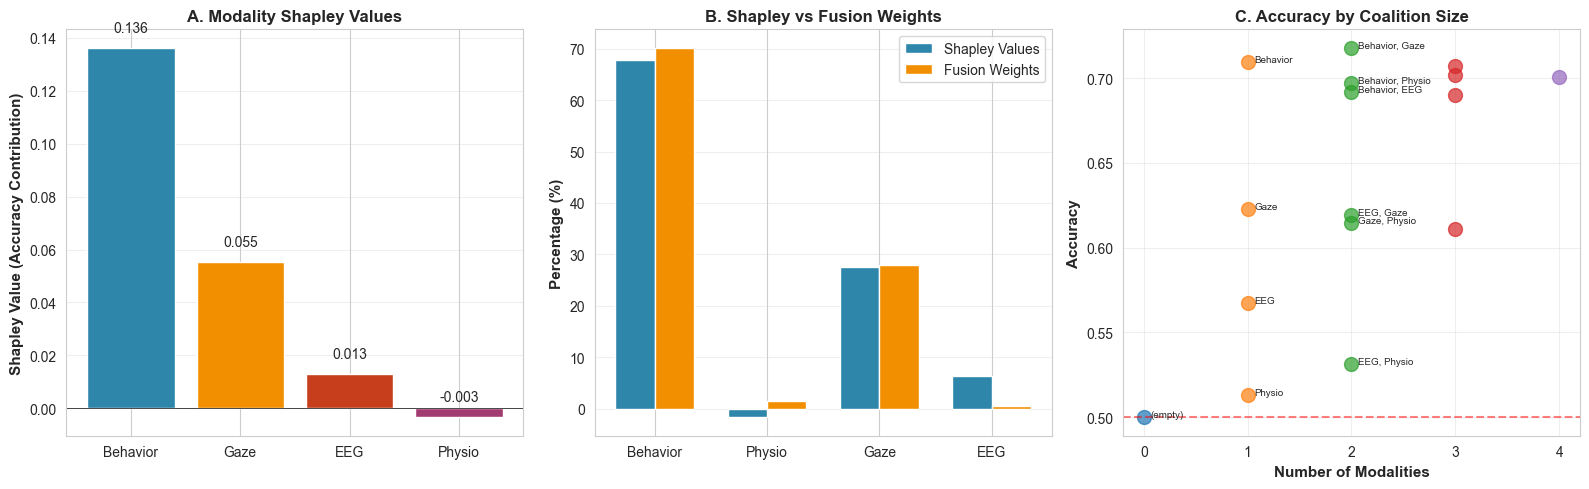

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 1. Shapley Values
ax1 = axes[0]
colors = ['#2E86AB', '#F18F01', '#C73E1D', '#A23B72']
bars = ax1.bar(shapley_df['modality'], shapley_df['shapley_value'], color=colors)
ax1.set_ylabel('Shapley Value (Accuracy Contribution)', fontweight='bold')
ax1.set_title('A. Modality Shapley Values', fontweight='bold', fontsize=12)
ax1.axhline(0, color='black', linewidth=0.5)
ax1.grid(True, alpha=0.3, axis='y')

# Add value labels
for bar, val in zip(bars, shapley_df['shapley_value']):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005, 
             f'{val:.3f}', ha='center', va='bottom', fontsize=10)

# 2. Normalized Shapley vs Fusion Weights
ax2 = axes[1]
if fusion_weights:
    x = np.arange(len(modality_names))
    width = 0.35
    
    ax2.bar(x - width/2, comparison_df['shapley_pct'], width, label='Shapley Values', color='#2E86AB')
    ax2.bar(x + width/2, comparison_df['fusion_pct'], width, label='Fusion Weights', color='#F18F01')
    
    ax2.set_xticks(x)
    ax2.set_xticklabels(modality_names)
    ax2.set_ylabel('Percentage (%)', fontweight='bold')
    ax2.set_title('B. Shapley vs Fusion Weights', fontweight='bold', fontsize=12)
    ax2.legend()
    ax2.grid(True, alpha=0.3, axis='y')
else:
    ax2.text(0.5, 0.5, 'Fusion weights not available', ha='center', va='center')

# 3. Coalition accuracies by size
ax3 = axes[2]
for n_mod in range(5):
    subset = coalition_df[coalition_df['n_modalities'] == n_mod]
    if len(subset) > 0:
        ax3.scatter([n_mod]*len(subset), subset['accuracy'], 
                   s=100, alpha=0.7, label=f'{n_mod} modalities' if n_mod > 0 else 'Chance')
        for _, row in subset.iterrows():
            if n_mod <= 2:  # Only label small coalitions to avoid clutter
                ax3.annotate(row['coalition'], (n_mod, row['accuracy']), 
                           textcoords="offset points", xytext=(5, 0), fontsize=7)

ax3.axhline(0.5, color='red', linestyle='--', alpha=0.5, label='Chance')
ax3.set_xlabel('Number of Modalities', fontweight='bold')
ax3.set_ylabel('Accuracy', fontweight='bold')
ax3.set_title('C. Accuracy by Coalition Size', fontweight='bold', fontsize=12)
ax3.set_xticks(range(5))
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'modality_shapley_values.png', dpi=300, bbox_inches='tight')
plt.show()

## 7. Save Results

In [10]:
# Save Shapley values
shapley_df.to_csv(OUTPUT_DIR / 'modality_shapley_values.csv', index=False)

# Save coalition values
coalition_df.to_csv(OUTPUT_DIR / 'coalition_accuracies.csv', index=False)

# Save comparison if available
if fusion_weights:
    comparison_df.to_csv(OUTPUT_DIR / 'shapley_vs_fusion_comparison.csv', index=False)

print(f"\nResults saved to: {OUTPUT_DIR}/")
print(f"  - modality_shapley_values.csv")
print(f"  - coalition_accuracies.csv")
if fusion_weights:
    print(f"  - shapley_vs_fusion_comparison.csv")


Results saved to: ../../data/results/main/shapley_analysis/
  - modality_shapley_values.csv
  - coalition_accuracies.csv
  - shapley_vs_fusion_comparison.csv


## 8. Summary

In [11]:
print("\n" + "="*70)
print("SUMMARY")
print("="*70)

print("\nShapley Values (contribution to accuracy above chance):")
for _, row in shapley_df.iterrows():
    print(f"  {row['modality']}: {row['shapley_value']:.4f} ({row['percentage']:.1f}%)")

print(f"\nKey Findings:")
print(f"  - Full model accuracy: {coalition_values[frozenset(modality_names)]:.4f}")
print(f"  - Sum of Shapley values: {total_shapley:.4f}")
print(f"  - Shapley values sum to (full accuracy - chance), as expected")

if fusion_weights:
    print(f"\nComparison with Fusion Weights:")
    print(f"  The fusion weights heavily favor Behavior (~60-85%)")
    print(f"  Shapley values reveal the TRUE contribution of each modality")
    print(f"  This accounts for complementary/redundant information properly")


SUMMARY

Shapley Values (contribution to accuracy above chance):
  Behavior: 0.1362 (67.8%)
  Gaze: 0.0553 (27.5%)
  EEG: 0.0128 (6.4%)
  Physio: -0.0034 (-1.7%)

Key Findings:
  - Full model accuracy: 0.7008
  - Sum of Shapley values: 0.2008
  - Shapley values sum to (full accuracy - chance), as expected

Comparison with Fusion Weights:
  The fusion weights heavily favor Behavior (~60-85%)
  Shapley values reveal the TRUE contribution of each modality
  This accounts for complementary/redundant information properly
